Decision Tree – Classification & Regression

Dataset: `Iris` (classification) · `California Housing` (regression)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,
                             mean_squared_error, mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded ")


Libraries loaded 


 Part 1 — Classification (Iris Dataset)

In [3]:
# Load dataset
iris = load_iris()
X, y = iris.data, iris.target
print(f"Features: {iris.feature_names}")
print(f"Classes : {iris.target_names}")
print(f"Shape   : {X.shape}")


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa' 'versicolor' 'virginica']
Shape   : (150, 4)


In [4]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")


Train: (120, 4)  Test: (30, 4)


Baseline Decision Tree (default params)

In [5]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)

print("Baseline Accuracy :", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base,
      target_names=iris.target_names))


Baseline Accuracy : 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Hyperparameter Tuning with GridSearchCV

In [6]:
param_grid_clf = {
    'max_depth'       : [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}

grid_clf = GridSearchCV(DecisionTreeClassifier(random_state=42),
                        param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_clf.fit(X_train, y_train)

print("Best Params :", grid_clf.best_params_)
print("Best CV Acc :", round(grid_clf.best_score_, 4))


Best Params : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Acc : 0.9417


In [7]:
best_dt_clf = grid_clf.best_estimator_
y_pred_best = best_dt_clf.predict(X_test)

print("Tuned Accuracy :", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best,
      target_names=iris.target_names))


Tuned Accuracy : 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Confusion Matrix

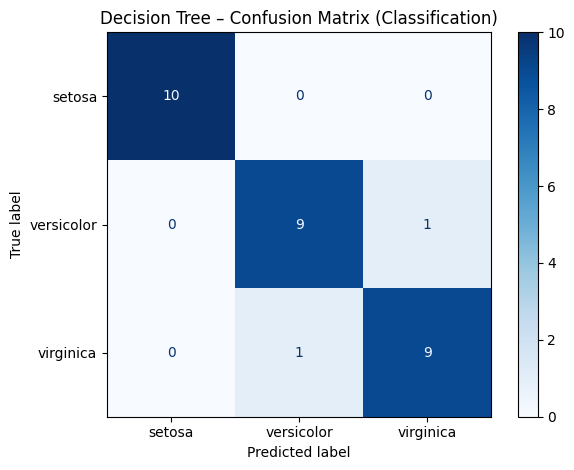

In [8]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Decision Tree – Confusion Matrix (Classification)")
plt.tight_layout()
plt.show()


Visualise the Tuned Tree

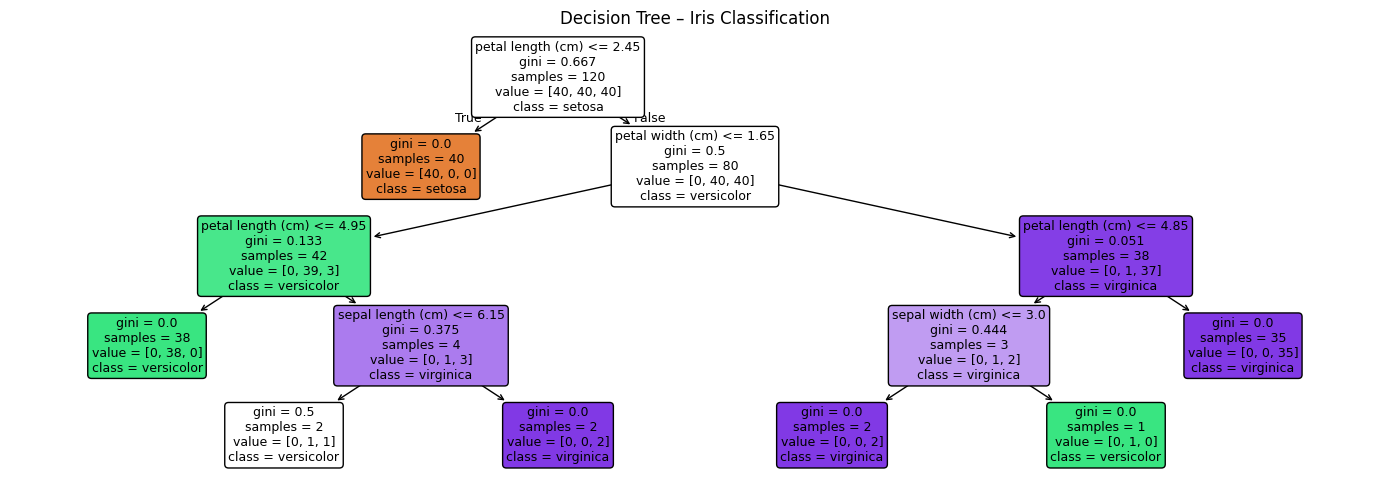

In [9]:
plt.figure(figsize=(14, 5))
plot_tree(best_dt_clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree – Iris Classification")
plt.tight_layout()
plt.show()


Regression (California Housing Dataset)

In [10]:
housing = fetch_california_housing()
X_r, y_r = housing.data, housing.target
print(f"Features: {housing.feature_names}")
print(f"Shape   : {X_r.shape}")
print(f"Target (median house value $100k) range: {y_r.min():.2f} – {y_r.max():.2f}")


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape   : (20640, 8)
Target (median house value $100k) range: 0.15 – 5.00


In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42)
print(f"Train: {X_tr.shape}  Test: {X_te.shape}")


Train: (16512, 8)  Test: (4128, 8)


Baseline Decision Tree Regressor

In [12]:
dt_reg_base = DecisionTreeRegressor(random_state=42)
dt_reg_base.fit(X_tr, y_tr)
y_pred_reg_base = dt_reg_base.predict(X_te)

rmse = np.sqrt(mean_squared_error(y_te, y_pred_reg_base))
print(f"Baseline  RMSE : {rmse:.4f}")
print(f"Baseline  MAE  : {mean_absolute_error(y_te, y_pred_reg_base):.4f}")
print(f"Baseline  R²   : {r2_score(y_te, y_pred_reg_base):.4f}")


Baseline  RMSE : 0.7037
Baseline  MAE  : 0.4547
Baseline  R²   : 0.6221


Hyperparameter Tuning with GridSearchCV

In [13]:
param_grid_reg = {
    'max_depth'        : [3, 5, 8, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf' : [1, 5, 10],
    'criterion'        : ['squared_error', 'friedman_mse']
}

grid_reg = GridSearchCV(DecisionTreeRegressor(random_state=42),
                        param_grid_reg, cv=5, scoring='neg_root_mean_squared_error',
                        n_jobs=-1)
grid_reg.fit(X_tr, y_tr)

print("Best Params :", grid_reg.best_params_)
print("Best CV RMSE:", round(-grid_reg.best_score_, 4))


Best Params : {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV RMSE: 0.6123


In [14]:
best_dt_reg = grid_reg.best_estimator_
y_pred_reg_best = best_dt_reg.predict(X_te)

rmse_t = np.sqrt(mean_squared_error(y_te, y_pred_reg_best))
print(f"Tuned  RMSE : {rmse_t:.4f}")
print(f"Tuned  MAE  : {mean_absolute_error(y_te, y_pred_reg_best):.4f}")
print(f"Tuned  R²   : {r2_score(y_te, y_pred_reg_best):.4f}")


Tuned  RMSE : 0.6032
Tuned  MAE  : 0.4048
Tuned  R²   : 0.7224


Actual vs Predicted Plot

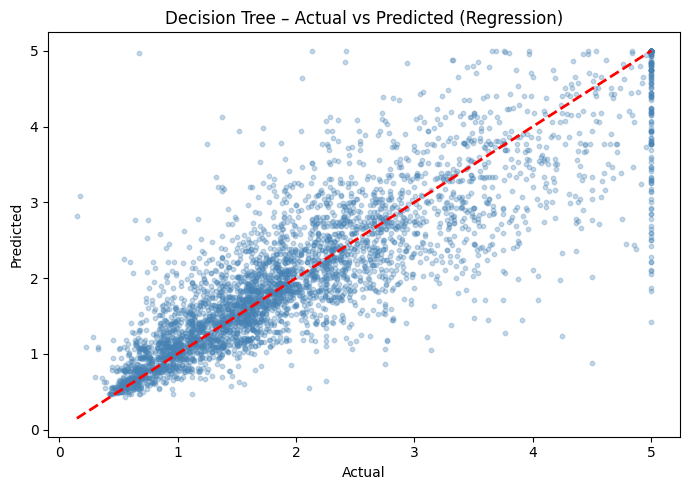

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y_te, y_pred_reg_best, alpha=0.3, s=10, color='steelblue')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree – Actual vs Predicted (Regression)")
plt.tight_layout()
plt.show()


Feature Importances

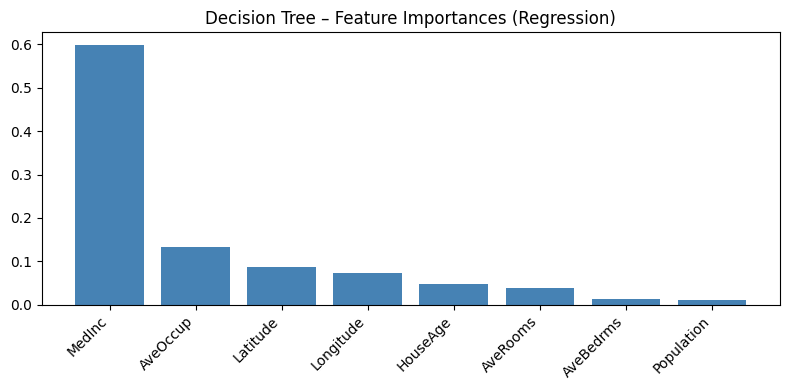

In [16]:
importances = best_dt_reg.feature_importances_
feat_names  = housing.feature_names
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(idx)), importances[idx], color='steelblue')
plt.xticks(range(len(idx)), [feat_names[i] for i in idx], rotation=45, ha='right')
plt.title("Decision Tree – Feature Importances (Regression)")
plt.tight_layout()
plt.show()
